### Imports

In [5]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42

### Paths

In [102]:
RAW_DATA_DIR = "../data/raw/COVID-19_Radiography_Dataset"
PADDED_DATA_DIR = "../data/padded"

CLASSES = [
    "Normal",
    "COVID",
    "Lung_Opacity",
    "Viral Pneumonia"
]

OUTPUT_DIR = "../data/processed/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Resize + conversion to float32

In [226]:
IMG_SIZE = 299

def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    return image.astype(np.float32)


def load_mask(mask_path):
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    return (mask > 0).astype(np.float32)

def apply_lung_mask(image, mask):
    return image * mask

### Padding removal

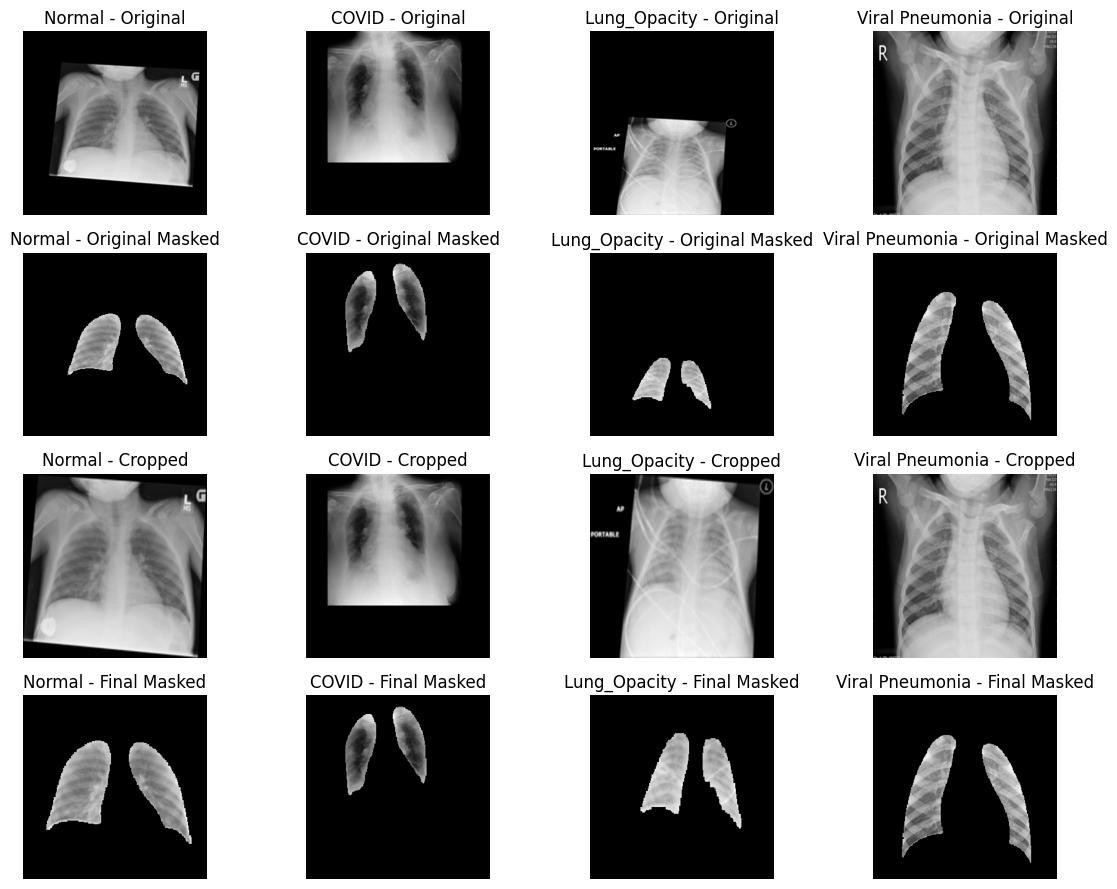

In [231]:
def remove_padding_resize(image, mask, threshold=1):
    original_size = image.shape[:2]
    
    _, binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(binary)
    x, y, w, h = cv2.boundingRect(coords)
    
    cropped_image = image[y:y+h, x:x+w]
    cropped_mask = mask[y:y+h, x:x+w]

    restored_image = cv2.resize(cropped_image, (original_size[1], original_size[0]))
    restored_mask = cv2.resize(cropped_mask, (original_size[1], original_size[0]), interpolation=cv2.INTER_NEAREST)  # INTER_NEAREST pour les masques binaires

    return restored_image, restored_mask


def show_premoval_examples():
    fig, axs = plt.subplots(4, 4, figsize=(12, 9))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(PADDED_DATA_DIR, cls)
        mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
        random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)  

        image = load_image(image_path)
        mask = load_mask(mask_path)

        restored_image, restored_mask = remove_padding_resize(image, mask)
        final_masked = apply_lung_mask(restored_image, restored_mask)

        axs[0, i].imshow(image, cmap="gray")
        axs[0, i].set_title(f"{cls} - Original")
        axs[1, i].imshow(apply_lung_mask(image, mask), cmap="grey")
        axs[1, i].set_title(f"{cls} - Original Masked")
        axs[2, i].imshow(restored_image, cmap="gray")
        axs[2, i].set_title(f"{cls} - Cropped")
        axs[3, i].imshow(final_masked, cmap="gray") 
        axs[3, i].set_title(f"{cls} - Final Masked")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_premoval_examples()

### CLAHE (contrast increase)

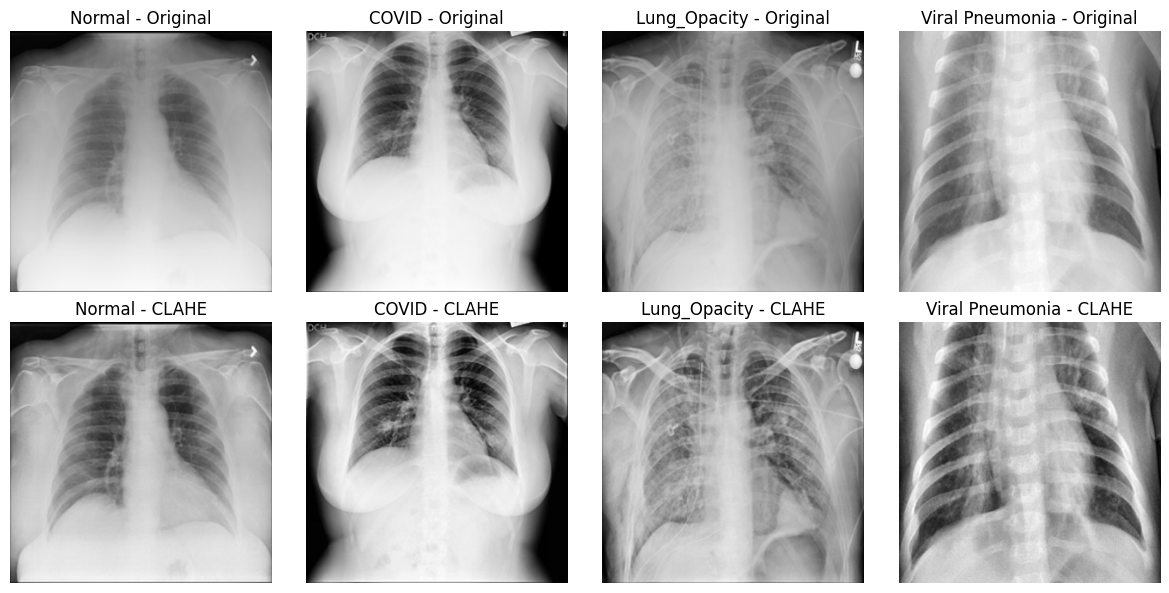

In [232]:
def apply_clahe(image):
    image_uint8 = image.astype(np.uint8)
    clahe = cv2.createCLAHE( clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image_uint8).astype(np.float32)


def show_clahe_examples():
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
        random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        image = load_image(image_path)
        clahe_image = apply_clahe(image)

        axs[0, i].imshow(image, cmap="gray")
        axs[0, i].set_title(f"{cls} - Original")
        axs[1, i].imshow(clahe_image, cmap="gray")
        axs[1, i].set_title(f"{cls} - CLAHE")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_clahe_examples()

### Mask segmentation

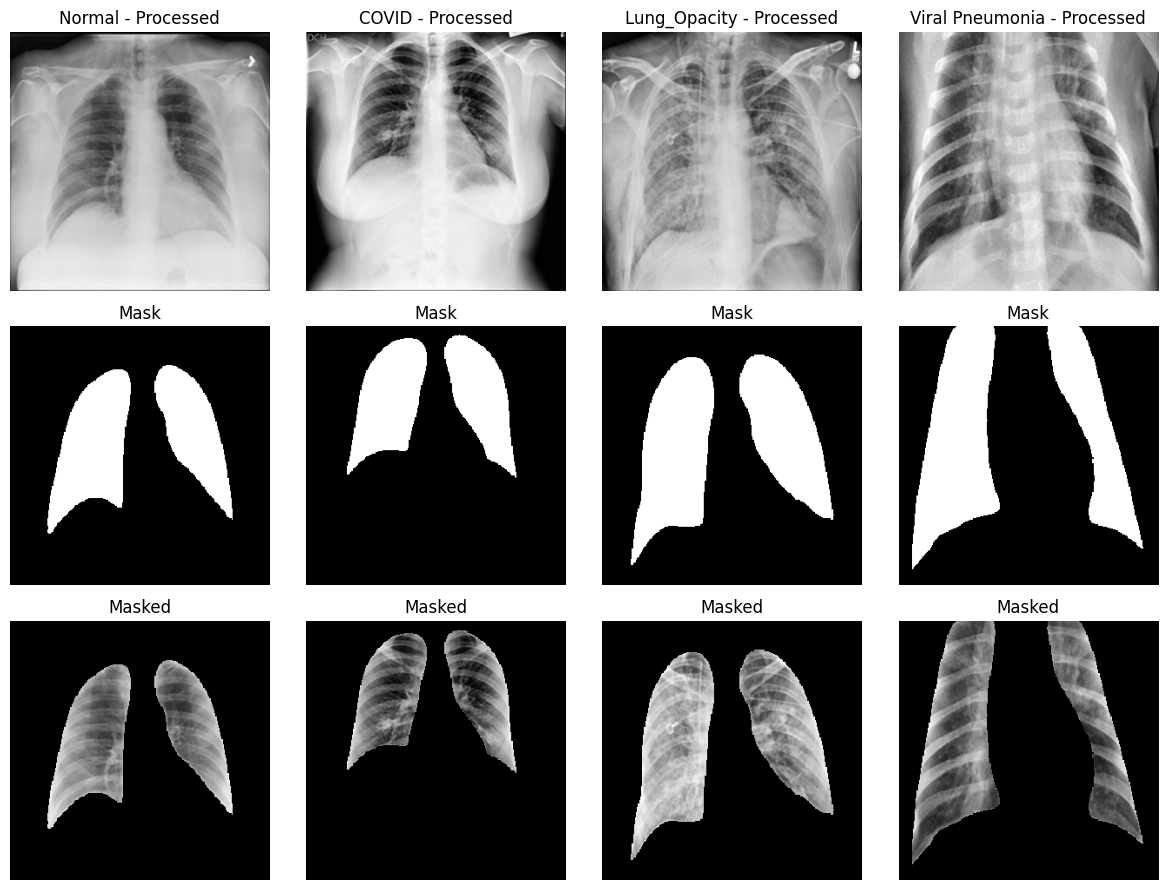

In [233]:
def show_mask_examples():
    fig, axs = plt.subplots(3, 4, figsize=(12, 9))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
        mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
        random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        image = load_image(image_path)
        image = apply_clahe(image)
        mask = load_mask(mask_path)
        masked_image = apply_lung_mask(image, mask)

        axs[0, i].imshow(image, cmap="gray")
        axs[0, i].set_title(f"{cls} - Processed")
        axs[1, i].imshow(mask, cmap="gray")
        axs[1, i].set_title("Mask")
        axs[2, i].imshow(masked_image, cmap="gray")
        axs[2, i].set_title("Masked")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_mask_examples()

### Normalization (inutile offline mais à faire lors de l'entrainement)

In [10]:
# def normalize_image(image):
#     image = image.astype(np.float32)
#     image = image / 255.0
#     return image

### Save pre-processed data

In [234]:
for cls in CLASSES:

    image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
    mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")

    output_class_dir = os.path.join(OUTPUT_DIR, "test", cls)
    os.makedirs(output_class_dir, exist_ok=True)
    image_names = os.listdir(image_dir)
    for image_name in tqdm(image_names, desc=cls):
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        # LOAD
        image = load_image(image_path)
        mask = load_mask(mask_path)
        # PADDING REMOVAL
        image, mask = remove_padding_resize(image, mask)
        # CLAHE
        image = apply_clahe(image)
        # MASK
        image = apply_lung_mask(image, mask)
        # SAVE
        output_path = os.path.join(output_class_dir, image_name)
        image_to_save = (image * 255).astype(np.uint8)
        cv2.imwrite(output_path, image_to_save)

print("Preprocessing completed.")

Viral Pneumonia: 100%|██████████| 1345/1345 [00:22<00:00, 58.54it/s] 

Preprocessing completed.


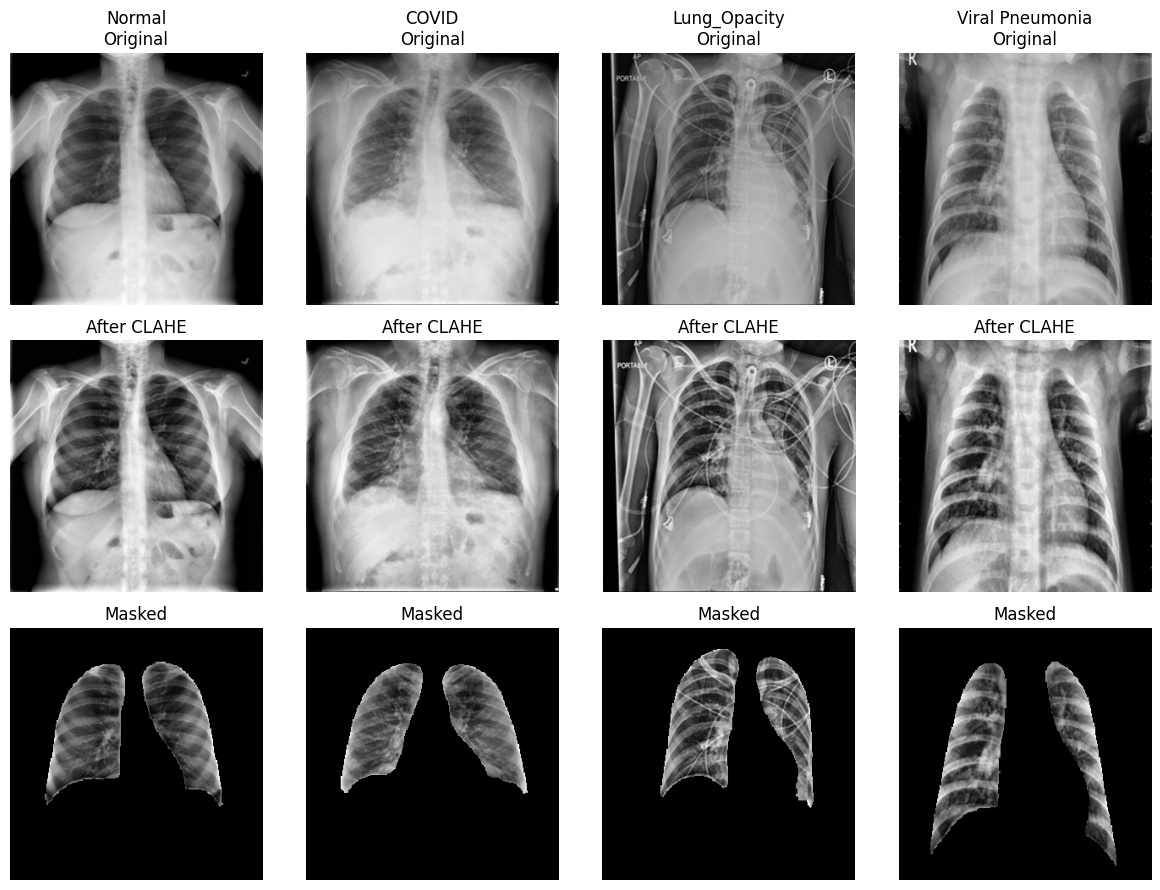

In [238]:
def show_preprocessed_examples():
    fig, axs = plt.subplots(3, 4, figsize=(12, 9))
    for i, cls in enumerate(CLASSES):
        image_dir = os.path.join(RAW_DATA_DIR, cls, "images")
        mask_dir = os.path.join(RAW_DATA_DIR, cls, "masks")
        #random.seed(SEED)
        image_name = random.choice(os.listdir(image_dir))
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        image = load_image(image_path)
        clahe_image = apply_clahe(image)
        mask = load_mask(mask_path)
        masked_image = apply_lung_mask(clahe_image, mask)

        axs[0, i].imshow(image, cmap="gray")
        axs[0, i].set_title(f"{cls}\nOriginal")
        axs[1, i].imshow(clahe_image, cmap="gray")
        axs[1, i].set_title("After CLAHE")
        axs[2, i].imshow(masked_image, cmap="gray")
        axs[2, i].set_title("Masked")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_preprocessed_examples()